IPL 2022 Capstone Project

The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string

venue : string

stage : string

team1 : string

team2 : string

toss_winner : string

toss_decision : string

first_ings_score : integer

second_ings_score : integer

match_winner : string

won_by : string

margin : integer

player_of_the_match : string

top_scorer : string

highscore : integer

best_bowling : string

best_bowling_fgure : string

gure : string

Loading the Libraries and DataSet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the DataSet

In [3]:
print(f"You have {df.shape[0]} rows and {df.shape[1]} columns in this dataset")

You have 74 rows and 20 columns in this dataset


Now let's see how many column have null values in total

In [4]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1. Which team won the most matches?

Text(0, 0.5, 'teams')

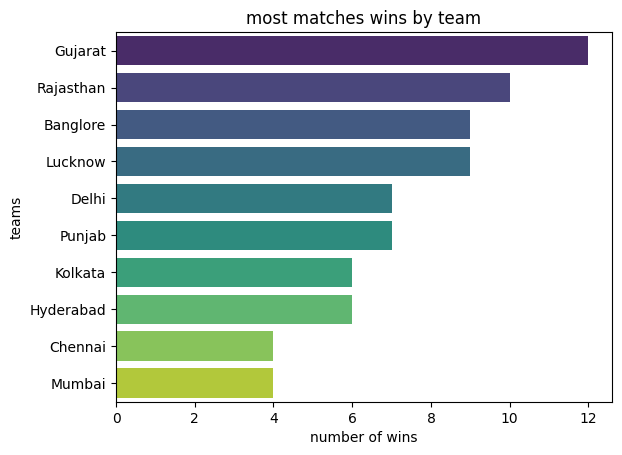

In [5]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values, palette='viridis')
plt.title('most matches wins by team')
plt.xlabel('number of wins')
plt.ylabel('teams')

2. Toss Decision Trends

Text(0, 0.5, 'toss decision of team')

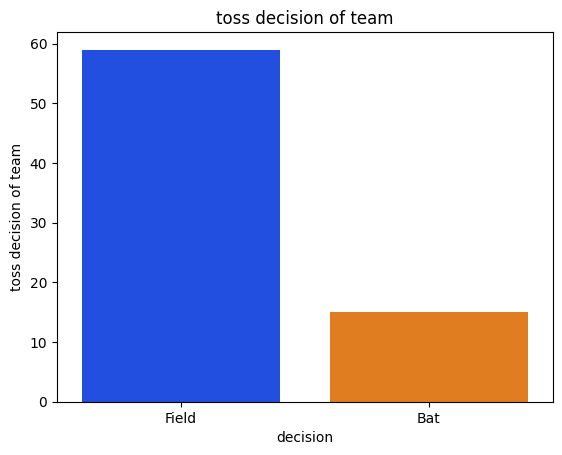

In [6]:
sns.countplot(x=df['toss_decision'],palette='bright')
plt.title('toss decision of team')
plt.xlabel('decision')
plt.ylabel('toss decision of team')

3. Toss Winner vs Match Winner

In [7]:
df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage = (df[df['toss_winner']==df['match_winner']]['match_id'].count()/df['match_id'].count())*100
print(f"Percentage of match won by toss winner is {percentage}%")

Percentage of match won by toss winner is 48.64864864864865%


4.How do teams win? (Runs vs Wicket)

Text(0.5, 0, 'teams')

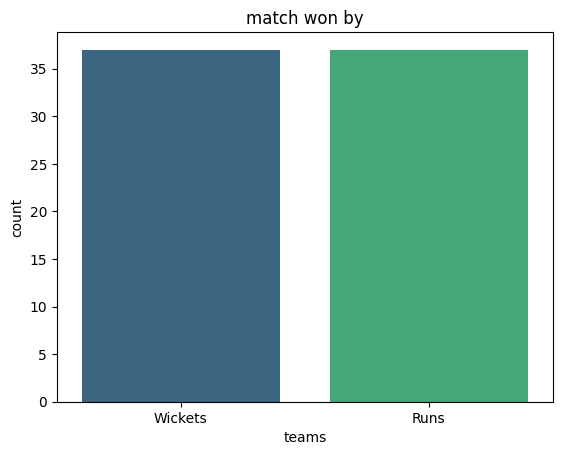

In [8]:
sns.countplot(x=df['won_by'],palette='viridis')
plt.title('match won by')
plt.xlabel('teams')

Key Player Performance 

1. Most "Player of the match" Awards

In [9]:
count = df['player_of_the_match'].value_counts().head(10)


Text(0, 0.5, 'players')

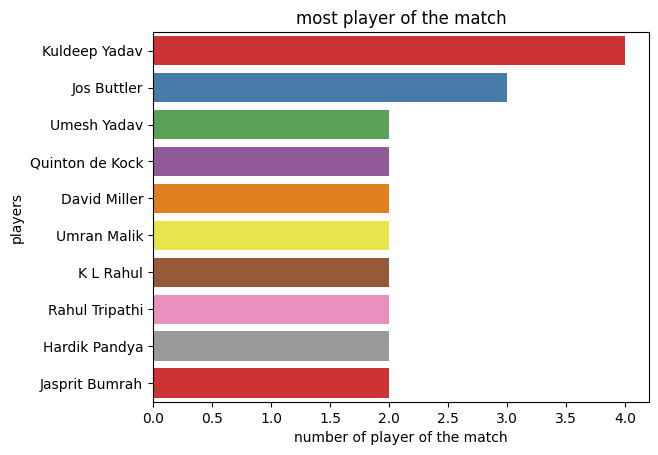

In [10]:
sns.barplot(y=count.index,x=count.values,palette='Set1')
plt.title('most player of the match')
plt.xlabel('number of player of the match')
plt.ylabel('players')

2. Top Scorers

In [11]:
high = df.groupby ('top_scorer')['highscore'].sum().sort_values(ascending = False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

Text(0, 0.5, 'top_players')

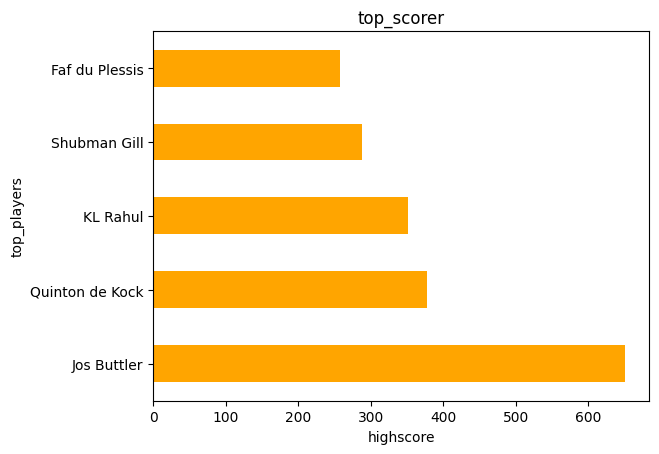

In [12]:
high.plot(kind='barh',color='orange')
plt.title('top_scorer')
plt.xlabel('highscore')
plt.ylabel('top_players')

10 Best figures

In [13]:
df['highest_wickets'] = df['best_bowling_figure'].str.extract(r'(\d+)')
df['highest_wickets'] = df['highest_wickets'].astype(int)

top_bowlers = df.groupby('best_bowling')['highest_wickets'] \
                .sum().sort_values(ascending=False).head(10)

top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wickets, dtype: int32

Text(0, 0.5, 'bowlers')

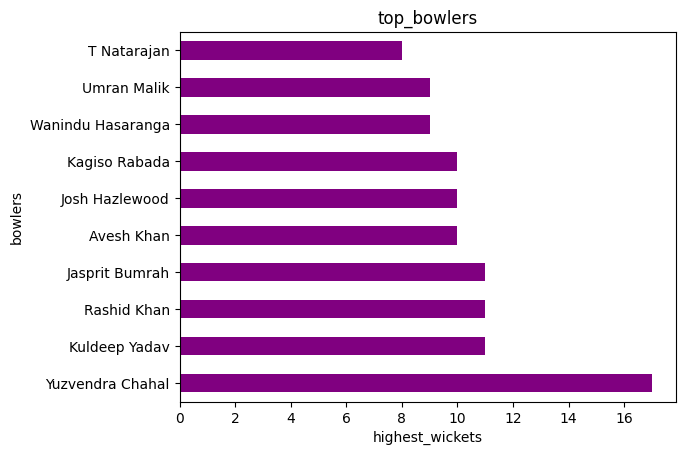

In [14]:
top_bowlers.plot(kind='barh',color='purple')
plt.title('top_bowlers')
plt.xlabel('highest_wickets')
plt.ylabel('bowlers')

Venue Analysis

Most Matches played By Venue

In [15]:
venue_count = df['venue'].value_counts()
venue_count

Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: venue, dtype: int64

Text(0, 0.5, 'venue')

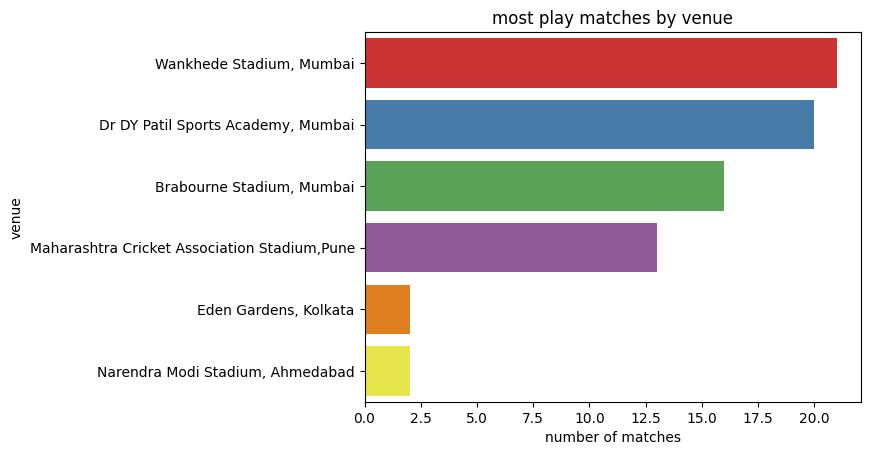

In [18]:
sns.barplot(y=venue_count.index,x=venue_count.values,palette='Set1')
plt.title('most play matches by venue')
plt.xlabel('number of matches')
plt.ylabel('venue')